## Ejercicio 1.

Implemente las estructuras de datos y algoritmos básicos para la solución de un **problema mediante algoritmos genéticos.** Pruebe estas rutinas y compare los resultados con un método de gradiente descendiente para buscar el mı́nimo global de las siguientes funciones:

#### B.

$$f(x,y)=(x^2 + y^2)^{0.25}\ [sin^2(50(x^2+y^2)^{0.1})+1], \quad x,y \in [-100,\ 100]$$

In [11]:
import numpy as np
import random 
import matplotlib.pyplot as plt

In [12]:
def decodificar(individuo,cantBits,alpha,beta): 
    mitad = cantBits // 2
    d_x = 0
    for i in range(mitad):
        d_x += 2**(mitad-1-i)*individuo[i]
    x = alpha + d_x*((beta-alpha)/(2**mitad - 1))

    d_y = 0
    for i in range(mitad):
        d_y += 2**(mitad-1-i)*individuo[mitad + i]
    y = alpha + d_y*((beta-alpha)/(2**mitad - 1))

    return (x,y)

In [13]:
def funcion(x,y):
    return ((x**2+y**2)**0.25) * ((np.sin(50*((x**2+y**2)**0.1))**2) + 1)

def gradiente(x, y):
    z = x**2 + y**2 + 1e-12 
        
    df_dz = 0.25 * (z**-0.75) * ((np.sin(50 * (z**0.1)))**2 + 1) + 10 * (z**-0.65) * np.sin(50 * (z**0.1)) * np.cos(50 * (z**0.1))
    
    grad_x = df_dz * 2 * x
    grad_y = df_dz * 2 * y
    
    return np.array([grad_x, grad_y])

In [14]:
def funcion_aptitud(individuo,cantBits,alpha,beta):
    x, y = decodificar(individuo,cantBits,alpha,beta)

    f = funcion(x,y)
    
    fitness = -f
    return fitness

In [15]:
def evaluar_poblacion(poblacion,cantBits, alpha,beta):
    aptitudes = np.zeros(poblacion.shape[0])

    for i in range(poblacion.shape[0]):
        aptitud = funcion_aptitud(poblacion[i,:],cantBits, alpha,beta)
        aptitudes[i] = aptitud
    
    return aptitudes 
    

In [16]:
def seleccion_natural(aptitudes):
    orden = np.arange(0,aptitudes.shape[0])
    matriz = np.c_[aptitudes,orden]

    indices = np.argsort(matriz[:, 0])[::-1]
    matriz = matriz[indices]

    cantVentanas = 10
    venta_act = 0

    padres = np.zeros((cantVentanas,))

    while venta_act<cantVentanas:
        tam_ventana = int((aptitudes.shape[0]-1)*((cantVentanas-venta_act)/cantVentanas))
        padres[venta_act] = matriz[random.randint(0,tam_ventana),1]
        venta_act += 1
    #ver que pasa si sale dos veces el mismo

    return padres

In [17]:
def operador_variacion(poblacion,padres,ind_mejorAptitud):
    nueva_poblacion = [poblacion[ind_mejorAptitud,:].copy()]

    prob_mutacion = 5 #%
    #mutacion
    for i in range(padres.shape[0]-1):
        padre = int(padres[i])
        cromosoma_nuevo = poblacion[padre,:].copy()
        if(random.randint(0,100)<prob_mutacion):
            bit_mutar = random.randint(0,poblacion.shape[1]-1)
            cromosoma_nuevo[bit_mutar] = not(cromosoma_nuevo[bit_mutar])
        nueva_poblacion.append(cromosoma_nuevo)


    #cruza
    for i in range(padres.shape[0]): 
        for j in range(i+1,padres.shape[0]):
            cant_bit_intercambio = random.randint(1,poblacion.shape[1]-1)
            padre1 = int(padres[i])
            padre2 = int(padres[j])
            hijo1 = np.r_[poblacion[padre1,0:cant_bit_intercambio],poblacion[padre2,cant_bit_intercambio:]]
            hijo2 = np.r_[poblacion[padre2,0:cant_bit_intercambio],poblacion[padre1,cant_bit_intercambio:]]
            nueva_poblacion.append(hijo1)
            nueva_poblacion.append(hijo2)

    poblacion = np.array(nueva_poblacion)
    return poblacion         

In [18]:
def grad_desc(x_inicial, y_inicial, mu, iteraciones):
    x = x_inicial
    y = y_inicial
    
    for _ in range(iteraciones):
        grad = gradiente(x, y)
        x_nuevo = x - mu * grad[0]
        y_nuevo = y - mu * grad[1]
        x = x_nuevo
        y = y_nuevo
            
    return x, y

In [19]:
def graficar(hist_aptitudes): 
    # hist_aptitudes tiene forma (individuos, generaciones)
    generaciones = np.arange(hist_aptitudes.shape[1])
            
    # Calculo en los individuos (filas)
    maximos = np.max(hist_aptitudes, axis=0)
    minimos = np.min(hist_aptitudes, axis=0)
    promedios = np.mean(hist_aptitudes, axis=0)
            
    plt.figure(figsize=(9, 5))
    plt.plot(generaciones, maximos, label="Mejor aptitud (Máximo)", color="green")
    plt.plot(generaciones, promedios, label="Aptitud promedio", color="blue", linestyle="--")
    plt.plot(generaciones, minimos, label="Peor aptitud (Mínimo)", color="red")
            
    plt.xlabel("Generación")
    plt.ylabel("Aptitud")
    plt.title("Historial de convergencia del Algoritmo Evolutivo")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.legend()
    plt.show()

8
Algoritmo Evolutivo: (x,y) = (-0.39, -0.39) y el minimo es f(x) = 0.89
Gradiente Descendente: (x, y) = (9.93, 9.93) y el minimo es f(x, y) = 3.75


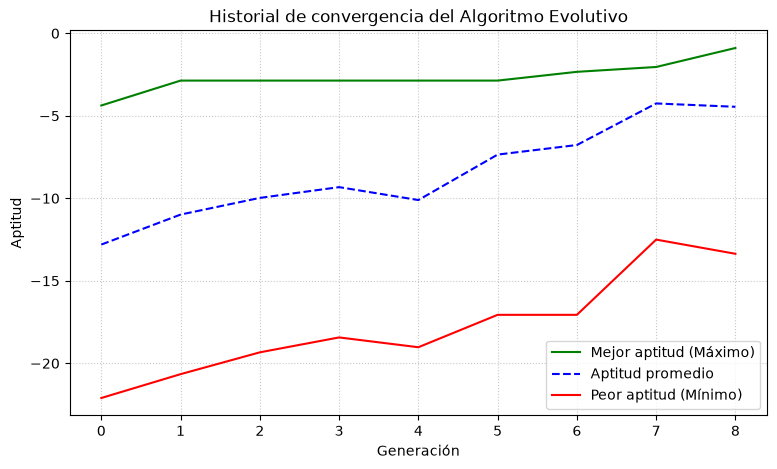

In [20]:
alpha = -100
beta = 100

N = 100
cantBitsInd = 16 # 8 para 'x' entre -100 y 100 y 8 para 'y' entre -100 y 100
cant_max_generaciones = 2000 

poblacion = np.random.randint(0,2,size=(N,cantBitsInd))

aptitudes = evaluar_poblacion(poblacion,cantBitsInd,alpha,beta)
mejorAptidud = np.max(aptitudes) 
ind_mejorAptitud = np.argmax(aptitudes)

generacion = 0
aptitudDeseada = -1

histAptitudes = [aptitudes]

while  mejorAptidud<aptitudDeseada and generacion < cant_max_generaciones:
    padres = seleccion_natural(aptitudes)
    poblacion = operador_variacion(poblacion,padres,ind_mejorAptitud)
    aptitudes = evaluar_poblacion(poblacion,cantBitsInd,alpha,beta)
    mejorAptidud = np.max(aptitudes) 
    ind_mejorAptitud = np.argmax(aptitudes)
    histAptitudes.append(aptitudes)
    generacion += 1

indiceMejorAptitud = np.argmax(aptitudes)
cromosoma = poblacion[indiceMejorAptitud,:]

print(generacion)
x,y = decodificar(cromosoma,cantBitsInd,alpha,beta)
print(f"Algoritmo Evolutivo: (x,y) = ({x:.2f}, {y:.2f}) y el minimo es f(x) = {funcion(x,y):.2f}")

x_ini = 10
y_ini = 10
tasa_aprendizaje_mu = 0.05
iters = 1000

x_min, y_min = grad_desc(x_ini, y_ini, tasa_aprendizaje_mu, iters)
print(f"Gradiente Descendente: (x, y) = ({x_min:.2f}, {y_min:.2f}) y el minimo es f(x, y) = {funcion(x_min,y_min):.2f}")

histAptitudes = np.array(histAptitudes).T
graficar(histAptitudes)